In [78]:
##An insurance company wants to predict whether a customer is likely to make a car insurance claim. 
#based on customer, vehicle, and policy information.

In [234]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix

In [235]:
df=pd.read_csv(r"C:\Users\nazma\Downloads\car_insurance_claim_prediction_1000.csv")

In [236]:
df

,Age,Gender,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,59,Female,1,26,0,1-2 Year,Yes,45454.0,157,258,0
1,49,Male,1,4,0,> 2 Years,Yes,63367.0,17,288,0
2,35,Male,1,26,0,1-2 Year,Yes,28650.0,68,285,1
3,63,Female,1,40,1,1-2 Year,No,50708.0,44,11,0
4,28,Male,1,9,1,< 1 Year,No,28190.0,61,97,0
...,...,...,...,...,...,...,...,...,...,...,...
995,55,Female,1,12,0,1-2 Year,No,34371.0,158,242,0
996,41,Female,1,33,0,1-2 Year,Yes,51999.0,106,103,1
997,57,Male,1,28,0,1-2 Year,Yes,37779.0,139,260,1
998,25,Male,1,8,0,> 2 Years,Yes,56075.0,17,259,0


In [237]:
df.head()

,Age,Gender,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,59,Female,1,26,0,1-2 Year,Yes,45454.0,157,258,0
1,49,Male,1,4,0,> 2 Years,Yes,63367.0,17,288,0
2,35,Male,1,26,0,1-2 Year,Yes,28650.0,68,285,1
3,63,Female,1,40,1,1-2 Year,No,50708.0,44,11,0
4,28,Male,1,9,1,< 1 Year,No,28190.0,61,97,0


In [238]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   1000 non-null   int64  
 1   Gender                990 non-null    str    
 2   Driving_License       1000 non-null   int64  
 3   Region_Code           1000 non-null   int64  
 4   Previously_Insured    1000 non-null   int64  
 5   Vehicle_Age           990 non-null    str    
 6   Vehicle_Damage        1000 non-null   str    
 7   Annual_Premium        990 non-null    float64
 8   Policy_Sales_Channel  1000 non-null   int64  
 9   Vintage               1000 non-null   int64  
 10  Response              1000 non-null   int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 101.3 KB


In [239]:
df.shape

(1000, 11)

In [240]:
df.describe()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,1000.000000,1000.000000,1000.00000,1000.000000,990.000000,1000.000000,1000.000000,1000.000000
mean,43.000000,0.946000,25.64900,0.449000,44979.138384,78.402000,153.897000,0.260000
std,12.945562,0.226131,14.69482,0.497641,11600.792992,45.649428,85.291776,0.438854
min,21.000000,0.000000,1.00000,0.000000,25002.000000,1.000000,10.000000,0.000000
25%,32.000000,1.000000,13.00000,0.000000,35058.000000,40.000000,80.000000,0.000000
50%,44.000000,1.000000,26.00000,0.000000,44781.000000,77.000000,151.000000,0.000000
75%,54.000000,1.000000,39.00000,1.000000,54968.000000,118.250000,230.250000,1.000000
max,65.000000,1.000000,50.00000,1.000000,64994.000000,159.000000,299.000000,1.000000


In [241]:
#DATA CLEANING

In [242]:
df.isnull().sum()

Age                      0
Gender                  10
Driving_License          0
Region_Code              0
Previously_Insured       0
Vehicle_Age             10
Vehicle_Damage           0
Annual_Premium          10
Policy_Sales_Channel     0
Vintage                  0
Response                 0
dtype: int64

In [243]:
df.duplicated().sum()

np.int64(0)

In [244]:
df.drop_duplicates(inplace=True)

In [245]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Vehicle_Age"] = df["Vehicle_Age"].fillna(df["Vehicle_Age"].mode()[0])

In [246]:
df["Annual_Premium"] = df["Annual_Premium"].fillna(
    df["Annual_Premium"].median())

In [247]:
df.isnull().sum()

Age                     0
Gender                  0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [248]:
df["Response"].value_counts()

Response
0    740
1    260
Name: count, dtype: int64

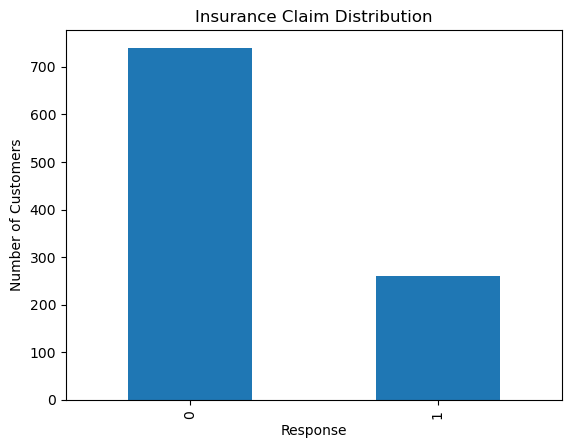

In [249]:
import matplotlib.pyplot as plt

df["Response"].value_counts().plot(kind="bar")

plt.title("Insurance Claim Distribution")
plt.xlabel("Response")
plt.ylabel("Number of Customers")
plt.show()

In [250]:
## train/test

In [251]:
df = df.drop("Age", axis=1)

In [252]:
df = pd.get_dummies(
    df,
    columns=["Gender", "Vehicle_Age", "Vehicle_Damage"],
    drop_first=True
)

In [253]:
df.head()

,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,26,0,45454.0,157,258,0,False,False,False,True
1,1,4,0,63367.0,17,288,0,True,False,True,True
2,1,26,0,28650.0,68,285,1,True,False,False,True
3,1,40,1,50708.0,44,11,0,False,False,False,False
4,1,9,1,28190.0,61,97,0,True,True,False,False


In [254]:
df.astype(float)

,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1.0,26.0,0.0,45454.0,157.0,258.0,0.0,0.0,0.0,0.0,1.0
1,1.0,4.0,0.0,63367.0,17.0,288.0,0.0,1.0,0.0,1.0,1.0
2,1.0,26.0,0.0,28650.0,68.0,285.0,1.0,1.0,0.0,0.0,1.0
3,1.0,40.0,1.0,50708.0,44.0,11.0,0.0,0.0,0.0,0.0,0.0
4,1.0,9.0,1.0,28190.0,61.0,97.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,12.0,0.0,34371.0,158.0,242.0,0.0,0.0,0.0,0.0,0.0
996,1.0,33.0,0.0,51999.0,106.0,103.0,1.0,0.0,0.0,0.0,1.0
997,1.0,28.0,0.0,37779.0,139.0,260.0,1.0,1.0,0.0,0.0,1.0
998,1.0,8.0,0.0,56075.0,17.0,259.0,0.0,1.0,0.0,1.0,1.0


In [255]:
X = df.drop("Response", axis=1)
y = df["Response"]

In [256]:
from sklearn.model_selection import train_test_split

In [257]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [258]:
from sklearn.preprocessing import StandardScaler

In [259]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [260]:
model=LogisticRegression()

In [261]:
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [262]:
pred=model.predict(X_test_scaled)

In [263]:
print(pred)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [264]:
print("accuracy",accuracy_score(y_test,pred))

accuracy 0.72


In [265]:
print("recall",recall_score(y_test,pred))

recall 0.19230769230769232


In [266]:
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))

precision 0.4166666666666667
f1 score 0.2631578947368421


In [267]:
print("classification_report",classification_report(y_test,pred))

classification_report               precision    recall  f1-score   support

           0       0.76      0.91      0.83       148
           1       0.42      0.19      0.26        52

    accuracy                           0.72       200
   macro avg       0.59      0.55      0.55       200
weighted avg       0.67      0.72      0.68       200



In [268]:
print("confusion matrix",confusion_matrix(y_test,pred))

confusion matrix [[134  14]
 [ 42  10]]


In [269]:
##KNN

In [270]:
model=KNeighborsClassifier(n_neighbors=2)

In [271]:
model.fit(X_train_scaled,y_train)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [272]:
pred=model.predict(X_test_scaled)

In [273]:
print(pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [274]:
print("accuracy",accuracy_score(y_test,pred))

accuracy 0.725


In [275]:
print("recall",recall_score(y_test,pred))
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))

recall 0.1346153846153846
precision 0.4117647058823529
f1 score 0.2028985507246377


In [276]:
print("classification_report",classification_report(y_test,pred))

classification_report               precision    recall  f1-score   support

           0       0.75      0.93      0.83       148
           1       0.41      0.13      0.20        52

    accuracy                           0.72       200
   macro avg       0.58      0.53      0.52       200
weighted avg       0.67      0.72      0.67       200



In [277]:
print("confusion matrix",confusion_matrix(y_test,pred))

confusion matrix [[138  10]
 [ 45   7]]


In [278]:
##DecisionTreeclassifier

In [279]:
model=DecisionTreeClassifier(max_depth=6)

In [280]:
model.fit(X_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [281]:
pred=model.predict(X_test_scaled)

In [282]:
print(pred)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [283]:
print("Accuracy score",accuracy_score(y_test,pred))
print("recall",recall_score(y_test,pred))
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))
print("classification_report",classification_report(y_test,pred))

Accuracy score 0.685
recall 0.19230769230769232
precision 0.3225806451612903
f1 score 0.24096385542168675
classification_report               precision    recall  f1-score   support

           0       0.75      0.86      0.80       148
           1       0.32      0.19      0.24        52

    accuracy                           0.69       200
   macro avg       0.54      0.53      0.52       200
weighted avg       0.64      0.69      0.66       200



In [284]:
##Random Forest

In [285]:
model=RandomForestClassifier(n_estimators=100)

In [286]:
model.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [287]:
pred=model.predict(X_test_scaled)

In [288]:
print("Accuracy score",accuracy_score(y_test,pred))
print("recall",recall_score(y_test,pred))
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))
print("classification_report",classification_report(y_test,pred))

Accuracy score 0.72
recall 0.21153846153846154
precision 0.4230769230769231
f1 score 0.28205128205128205
classification_report               precision    recall  f1-score   support

           0       0.76      0.90      0.83       148
           1       0.42      0.21      0.28        52

    accuracy                           0.72       200
   macro avg       0.59      0.56      0.55       200
weighted avg       0.68      0.72      0.68       200



In [289]:
from sklearn.ensemble import AdaBoostClassifier

In [290]:
model=AdaBoostClassifier(n_estimators=100)

In [291]:
model.fit(X_train_scaled,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [292]:
pred=model.predict(X_test_scaled)

In [293]:
print("Accuracy score",accuracy_score(y_test,pred))
print("recall",recall_score(y_test,pred))
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))
print("classification_report",classification_report(y_test,pred))

Accuracy score 0.69
recall 0.038461538461538464
precision 0.14285714285714285
f1 score 0.06060606060606061
classification_report               precision    recall  f1-score   support

           0       0.73      0.92      0.81       148
           1       0.14      0.04      0.06        52

    accuracy                           0.69       200
   macro avg       0.44      0.48      0.44       200
weighted avg       0.58      0.69      0.62       200



In [294]:
from xgboost import XGBClassifier

In [295]:
model=XGBClassifier(n_estimators=100)

In [296]:
model.fit(X_train_scaled,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [297]:
pred=model.predict(X_test_scaled)

In [298]:
print("Accuracy score",accuracy_score(y_test,pred))
print("recall",recall_score(y_test,pred))
print("precision",precision_score(y_test,pred))
print("f1 score",f1_score(y_test,pred))
print("classification_report",classification_report(y_test,pred))

Accuracy score 0.705
recall 0.21153846153846154
precision 0.3793103448275862
f1 score 0.2716049382716049
classification_report               precision    recall  f1-score   support

           0       0.76      0.88      0.82       148
           1       0.38      0.21      0.27        52

    accuracy                           0.70       200
   macro avg       0.57      0.54      0.54       200
weighted avg       0.66      0.70      0.67       200



In [309]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Hyperparameters
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': False}


In [310]:
pred = best_model.predict(X_test)

In [311]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

Accuracy: 0.67
Precision: 0.4
Recall: 0.5384615384615384
F1 Score: 0.45901639344262296

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.72      0.76       148
           1       0.40      0.54      0.46        52

    accuracy                           0.67       200
   macro avg       0.61      0.63      0.61       200
weighted avg       0.71      0.67      0.68       200


Confusion Matrix:

[[106  42]
 [ 24  28]]


In [312]:
import numpy as np
from sklearn.metrics import f1_score

# Get probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

# Find the best threshold
for threshold in np.arange(0.30, 0.71, 0.01):
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    score = f1_score(y_test, y_pred_threshold)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", round(best_threshold, 2))
print("Best F1 Score:", round(best_f1, 4))

Best Threshold: 0.51
Best F1 Score: 0.4828


In [313]:
final_pred = (y_prob >= best_threshold).astype(int)

In [314]:
print("Final Accuracy:", accuracy_score(y_test, final_pred))
print("Final Precision:", precision_score(y_test, final_pred))
print("Final Recall:", recall_score(y_test, final_pred))
print("Final F1 Score:", f1_score(y_test, final_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, final_pred))

Final Accuracy: 0.7
Final Precision: 0.4375
Final Recall: 0.5384615384615384
Final F1 Score: 0.4827586206896552

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       148
           1       0.44      0.54      0.48        52

    accuracy                           0.70       200
   macro avg       0.63      0.65      0.64       200
weighted avg       0.72      0.70      0.71       200


Confusion Matrix:

[[112  36]
 [ 24  28]]


In [315]:
import joblib
joblib.dump(best_model, "car_insurance_model.pkl")
print("Model saved successfully")

Model saved successfully
